# FRED / ALFRED API — exploration

Lexis Markets TODO: macro, rates, CPI/PPI, FX. See `README.md`.

Keys in repo root `.env` (`FRED_API_KEY`). Loaded below via `python-dotenv`.

In [6]:
import os
import requests
import pandas as pd
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

API_KEY = os.environ["FRED_API_KEY"]
BASE = "https://api.stlouisfed.org/fred"

def fred_get(path, **params):
    params["api_key"] = API_KEY
    params.setdefault("file_type", "json")
    r = requests.get(f"{BASE}/{path}", params=params)
    r.raise_for_status()
    return r.json()

## Starter series — Markets macro

In [7]:
STARTER = {
    "DFF": "Fed Funds",
    "DGS10": "10Y Treasury",
    "CPIAUCSL": "CPI All Items",
    "CPILFESL": "Core CPI",
    "UNRATE": "Unemployment",
    "DCOILWTICO": "WTI Oil",
    "DTWEXBGS": "Trade Weighted USD",
}

rows = []
for sid, label in STARTER.items():
    meta = fred_get("series", series_id=sid)["seriess"][0]
    obs = fred_get("series/observations", series_id=sid, limit=5)
    rows.append({
        "series_id": sid,
        "label": label,
        "title": meta["title"],
        "frequency": meta["frequency_short"],
        "units": meta["units_short"],
        "obs_start": meta["observation_start"],
        "obs_end": meta["observation_end"],
        "last_updated": meta["last_updated"],
        "sample_tail": obs["observations"][-3:],
    })

pd.DataFrame(rows)

,series_id,label,title,frequency,units,obs_start,obs_end,last_updated,sample_tail
0,DFF,Fed Funds,Federal Funds Effective Rate,D,%,1954-07-01,2026-08-20,2026-08-21 15:16:32-05,"[{'realtime_start': '2026-08-22', 'realtime_en..."
1,DGS10,10Y Treasury,Market Yield on U.S. Treasury Securities at 10...,D,%,1962-01-02,2026-08-20,2026-08-21 15:16:35-05,"[{'realtime_start': '2026-08-22', 'realtime_en..."
2,CPIAUCSL,CPI All Items,Consumer Price Index for All Urban Consumers: ...,M,Index 1982-1984=100,1947-01-01,2026-07-01,2026-08-12 09:10:19-05,"[{'realtime_start': '2026-08-12', 'realtime_en..."
3,CPILFESL,Core CPI,Consumer Price Index for All Urban Consumers: ...,M,Index 1982-1984=100,1957-01-01,2026-07-01,2026-08-12 09:10:19-05,"[{'realtime_start': '2026-08-21', 'realtime_en..."
4,UNRATE,Unemployment,Unemployment Rate,M,%,1948-01-01,2026-07-01,2026-08-07 08:31:41-05,"[{'realtime_start': '2026-08-08', 'realtime_en..."
5,DCOILWTICO,WTI Oil,Crude Oil Prices: West Texas Intermediate (WTI...,D,$ per Barrel,1986-01-02,2026-08-18,2026-08-19 12:17:20-05,"[{'realtime_start': '2026-08-22', 'realtime_en..."
6,DTWEXBGS,Trade Weighted USD,Nominal Broad U.S. Dollar Index,D,Index Jan 2006=100,2006-01-02,2026-08-14,2026-08-17 16:14:22-05,"[{'realtime_start': '2026-08-17', 'realtime_en..."


## Pull one full series + quick plot

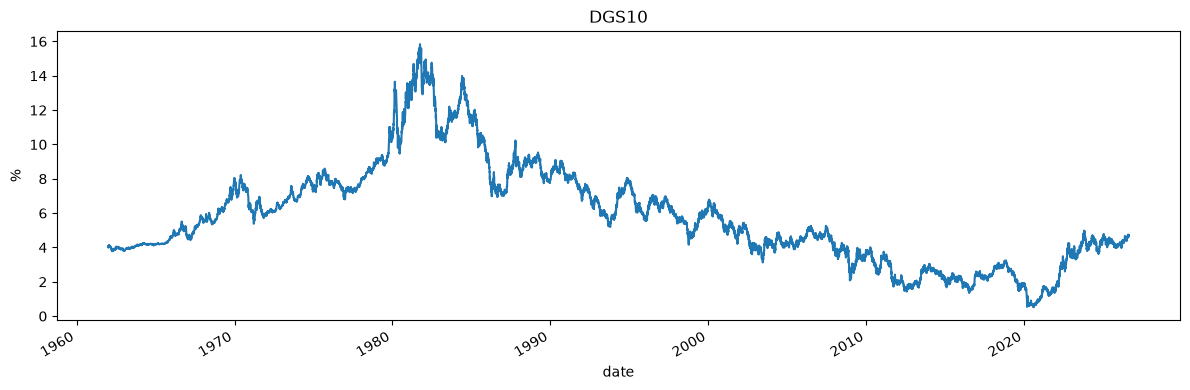

In [8]:
import matplotlib.pyplot as plt

sid = "DGS10"
data = fred_get("series/observations", series_id=sid)
df = pd.DataFrame(data["observations"])
df["date"] = pd.to_datetime(df["date"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"]).set_index("date")

df["value"].plot(figsize=(12, 4), title=sid)
plt.ylabel("%")
plt.tight_layout()

## Discover releases (CPI, H.15 rates, FX)

In [9]:
releases = fred_get("releases", limit=1000)["releases"]
rel_df = pd.DataFrame(releases)
keywords = ["consumer price", "interest rate", "foreign exchange", "producer price", "employment"]
mask = rel_df["name"].str.lower().apply(lambda s: any(k in s for k in keywords))
rel_df.loc[mask, ["id", "name", "press_release"]]

,id,name,press_release
8,10,Consumer Price Index,True
9,11,Employment Cost Index,True
12,15,G.5 Foreign Exchange Rates,True
13,17,H.10 Foreign Exchange Rates,True
14,18,H.15 Selected Interest Rates,True
21,46,Producer Price Index,True
24,50,Employment Situation,True
49,94,"Survey of Secondary Market Prices and Yields, ...",True
64,112,State Employment and Unemployment,True
65,113,Metropolitan Area Employment and Unemployment,True


## ALFRED smoke test — UNRATE as known on 2010-01-01

In [10]:
alfred = fred_get(
    "series/observations",
    series_id="UNRATE",
    realtime_start="2010-01-01",
    realtime_end="2010-01-01",
    observation_start="2008-01-01",
    observation_end="2010-12-01",
)
pd.DataFrame(alfred["observations"]).tail(10)

,realtime_start,realtime_end,date,value
13,2010-01-01,2010-01-01,2009-02-01,8.1
14,2010-01-01,2010-01-01,2009-03-01,8.5
15,2010-01-01,2010-01-01,2009-04-01,8.9
16,2010-01-01,2010-01-01,2009-05-01,9.4
17,2010-01-01,2010-01-01,2009-06-01,9.5
18,2010-01-01,2010-01-01,2009-07-01,9.4
19,2010-01-01,2010-01-01,2009-08-01,9.7
20,2010-01-01,2010-01-01,2009-09-01,9.8
21,2010-01-01,2010-01-01,2009-10-01,10.2
22,2010-01-01,2010-01-01,2009-11-01,10.0


## Series universe catalog (metadata only)

Walk every **release → series** (no observations). Cache to `fred_series_catalog.parquet`.

Then filter to **national macro**: drop regional/geo releases, granular employment breakdowns, and prefer SA over NSA twins.

In [11]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CATALOG_PATH = Path("fred_series_catalog.parquet")


def fred_paginate(path, page_size=1000, sleep=0.55, **params):
    params = {**params, "limit": page_size}
    offset = 0
    while True:
        data = fred_get(path, offset=offset, **params)
        key = next(k for k in data if k not in {
            "realtime_start", "realtime_end", "count", "offset", "limit", "order_by", "sort_order"
        })
        batch = data[key]
        if not batch:
            break
        yield from batch
        offset += page_size
        if offset >= data["count"]:
            break
        time.sleep(sleep)


if CATALOG_PATH.exists():
    catalog = pd.read_parquet(CATALOG_PATH)
    print(f"loaded cache: {len(catalog):,} series")
else:
    rows = []
    releases = list(fred_paginate("releases", limit=1000))
    print(f"releases: {len(releases)}")
    for rel in releases:
        for s in fred_paginate("release/series", release_id=rel["id"], limit=1000):
            rows.append({**s, "release_id": rel["id"], "release_name": rel["name"]})
        time.sleep(0.55)
    catalog = pd.DataFrame(rows).drop_duplicates("id").reset_index(drop=True)
    catalog.to_parquet(CATALOG_PATH)
    print(f"fetched + cached: {len(catalog):,} unique series")

catalog["observation_start"] = pd.to_datetime(catalog["observation_start"])
catalog["observation_end"] = pd.to_datetime(catalog["observation_end"])
catalog["span_years"] = (catalog["observation_end"] - catalog["observation_start"]).dt.days / 365.25
catalog.head()

loaded cache: 845,503 series


,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes,release_id,release_name,span_years
0,SBCSS10B0V0FRB,2026-08-22,2026-08-22,Small Business Credit Survey: Experienced at L...,2017-01-01,2025-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-07-30 14:06:26-05,2,2,The Small Business Credit Survey (SBCS) is an ...,1,Small Business Credit Survey,8.0
1,SBCSS10B10V0FRB,2026-08-22,2026-08-22,Small Business Credit Survey: Experienced at L...,2017-01-01,2025-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-07-30 14:06:34-05,0,0,The Small Business Credit Survey (SBCS) is an ...,1,Small Business Credit Survey,8.0
2,SBCSS10B10V1FRB,2026-08-22,2026-08-22,Small Business Credit Survey: Experienced at L...,2017-01-01,2025-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-07-30 14:06:25-05,1,1,The Small Business Credit Survey (SBCS) is an ...,1,Small Business Credit Survey,8.0
3,SBCSS10B11V0FRB,2026-08-22,2026-08-22,Small Business Credit Survey: Experienced at L...,2017-01-01,2025-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-07-30 14:06:27-05,1,1,The Small Business Credit Survey (SBCS) is an ...,1,Small Business Credit Survey,8.0
4,SBCSS10B11V1FRB,2026-08-22,2026-08-22,Small Business Credit Survey: Experienced at L...,2017-01-01,2025-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-07-30 14:06:41-05,1,1,The Small Business Credit Survey (SBCS) is an ...,1,Small Business Credit Survey,8.0


In [12]:
GEO_RELEASE = re.compile(
    r"regional|county|counties|\bstates\b|msa|metropolitan|census region|"
    r"freddie mac region|bls region|bea region|state & area|state and area|"
    r"area economic|city average|state retail|state unemployment",
    re.I,
)
GEO_TITLE = re.compile(
    r"county|msa|metropolitan|,\s*[A-Z]{2}\b|\bin [A-Z][a-z]+ County\b|"
    r"state unemployment|unemployment rate in ",
    re.I,
)
EMP_TITLE = re.compile(
    r"all employees:|employment in |average hourly earnings|job openings:|"
    r"initial claims|continuing claims|nonfarm payrolls -|payers of ",
    re.I,
)

macro = catalog[~catalog["release_name"].str.contains(GEO_RELEASE, na=False)].copy()
macro = macro[~macro["title"].str.contains(GEO_TITLE, na=False)]
macro = macro[~macro["title"].str.contains(EMP_TITLE, na=False)]

macro["title_norm"] = (
    macro["title"]
    .str.replace(r"\(Seasonally Adjusted\)", "", regex=True)
    .str.replace(r"\(Not Seasonally Adjusted\)", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
sa_titles = set(macro.loc[macro["seasonal_adjustment_short"] == "SA", "title_norm"])
macro = macro[
    (macro["seasonal_adjustment_short"] == "SA")
    | (~macro["title_norm"].isin(sa_titles))
].copy()

print(f"all releases series: {len(catalog):,}")
print(f"macro filtered:        {len(macro):,}")
print(f"reduction:             {100 * (1 - len(macro) / len(catalog)):.1f}%")
macro.to_parquet("fred_series_macro.parquet")
macro["frequency_short"].value_counts()

all releases series: 845,503
macro filtered:        293,233
reduction:             65.3%


frequency_short
A          160578
Q           59824
M           56686
D           11244
W            2613
SA           1399
5Y            822
NA             35
10 Year        19
BW             12
10Y             1
Name: count, dtype: int64

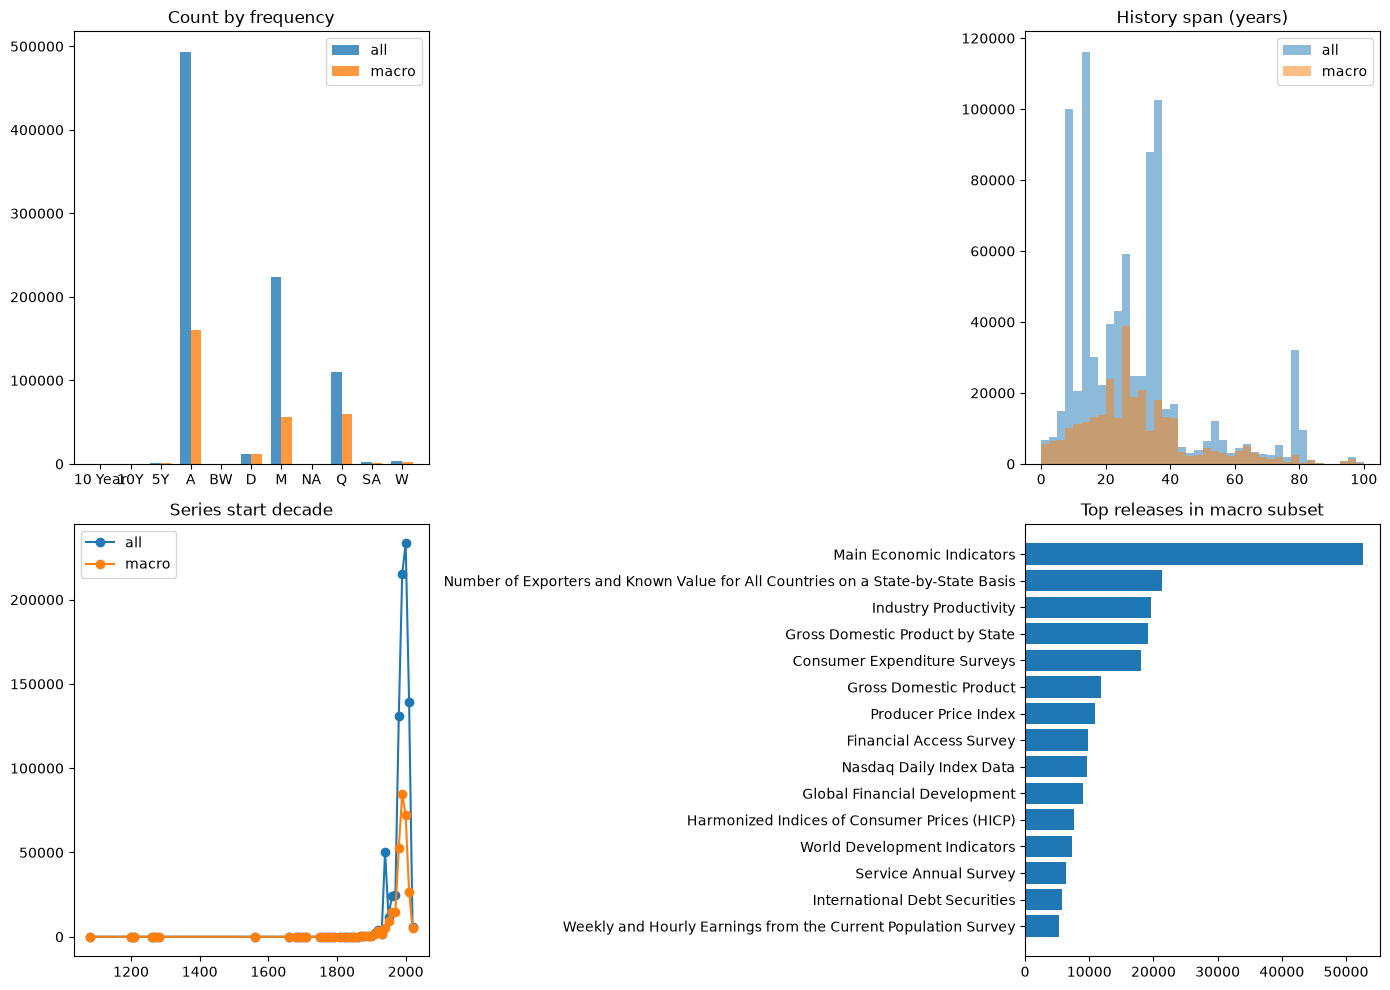

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

freq_all = catalog["frequency_short"].value_counts().sort_index()
freq_macro = macro["frequency_short"].value_counts().reindex(freq_all.index, fill_value=0)
x = np.arange(len(freq_all))
w = 0.35
axes[0, 0].bar(x - w/2, freq_all.values, w, label="all", alpha=0.8)
axes[0, 0].bar(x + w/2, freq_macro.values, w, label="macro", alpha=0.8)
axes[0, 0].set_xticks(x, freq_all.index)
axes[0, 0].set_title("Count by frequency")
axes[0, 0].legend()

axes[0, 1].hist(catalog["span_years"].clip(0, 100), bins=40, alpha=0.5, label="all")
axes[0, 1].hist(macro["span_years"].clip(0, 100), bins=40, alpha=0.5, label="macro")
axes[0, 1].set_title("History span (years)")
axes[0, 1].legend()

decade_all = (catalog["observation_start"].dt.year // 10 * 10).value_counts().sort_index()
decade_macro = (macro["observation_start"].dt.year // 10 * 10).value_counts().sort_index()
decade_macro = decade_macro.reindex(decade_all.index, fill_value=0)
axes[1, 0].plot(decade_all.index, decade_all.values, marker="o", label="all")
axes[1, 0].plot(decade_all.index, decade_macro.values, marker="o", label="macro")
axes[1, 0].set_title("Series start decade")
axes[1, 0].legend()

top = macro["release_name"].value_counts().head(15)
axes[1, 1].barh(top.index[::-1], top.values[::-1])
axes[1, 1].set_title("Top releases in macro subset")
plt.tight_layout()

,id,title,frequency_short,seasonal_adjustment_short,observation_start,observation_end,span_years,release_name
0,SBCSS10B0V0FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
1,SBCSS10B10V0FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
2,SBCSS10B10V1FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
3,SBCSS10B11V0FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
4,SBCSS10B11V1FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
5,SBCSS10B1V1FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
6,SBCSS10B1V2FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
7,SBCSS10B1V3FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
8,SBCSS10B1V4FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey
9,SBCSS10B1V5FRB,Small Business Credit Survey: Experienced at L...,A,NSA,2017-01-01,2025-01-01,8.0,Small Business Credit Survey


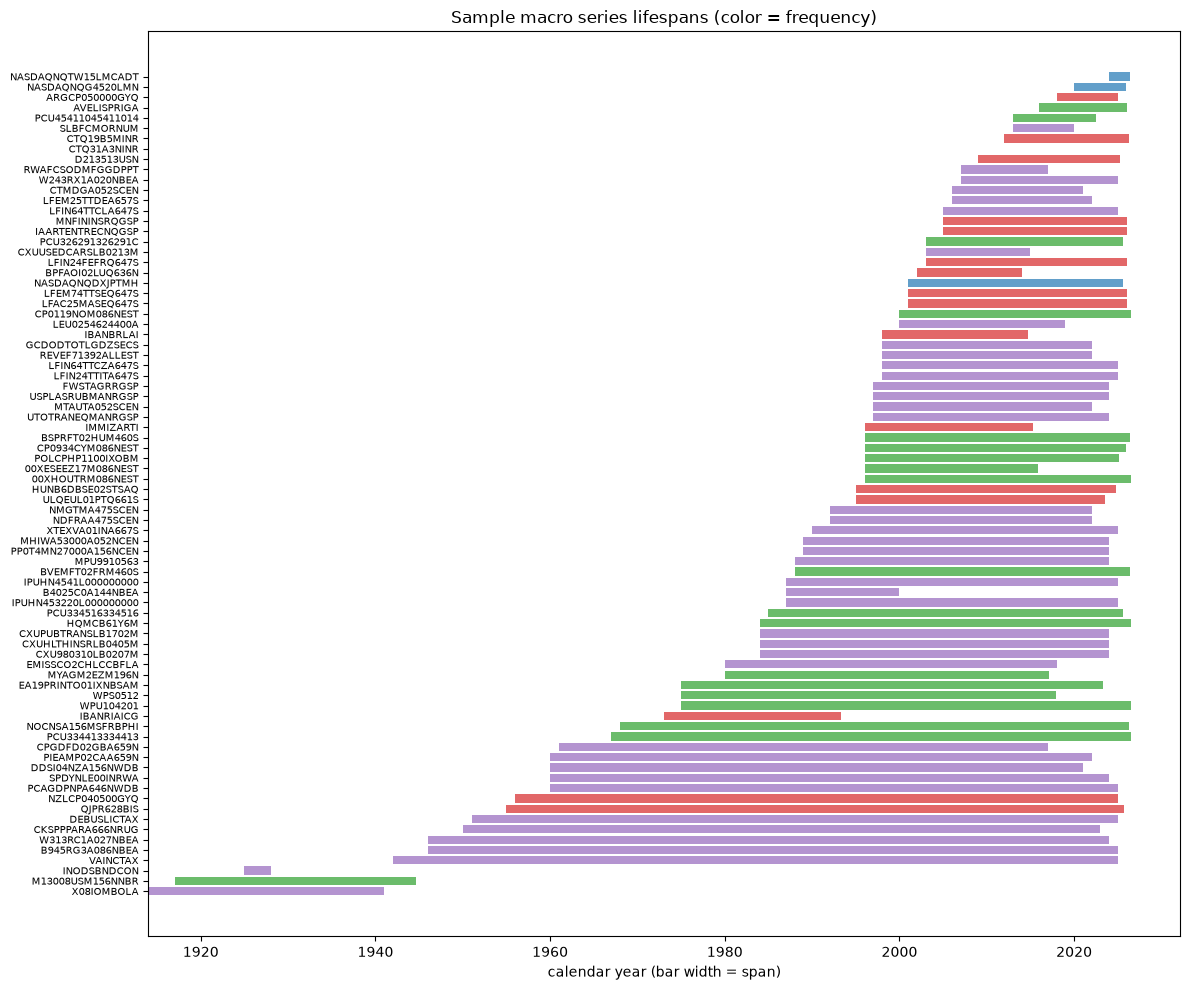

In [15]:
sample = macro.sample(min(80, len(macro)), random_state=0).sort_values("observation_start")
fig, ax = plt.subplots(figsize=(12, 10))
colors = {"D": "C0", "W": "C1", "M": "C2", "Q": "C3", "A": "C4"}
for i, row in enumerate(sample.itertuples()):
    c = colors.get(row.frequency_short, "gray")
    ax.barh(i, row.span_years, left=row.observation_start.year, height=0.8, color=c, alpha=0.7)
ax.set_yticks(range(len(sample)))
ax.set_yticklabels(sample["id"], fontsize=7)
ax.set_xlabel("calendar year (bar width = span)")
ax.set_title("Sample macro series lifespans (color = frequency)")
plt.tight_layout()

macro[["id", "title", "frequency_short", "seasonal_adjustment_short", "observation_start", "observation_end", "span_years", "release_name"]].head(20)

## Type clusters (macro subset)

Rule-based buckets from `title` + `release_name` (first match wins). Shows what still dominates after the geo/employment filter.

C:\Users\Peter\AppData\Local\Temp\ipykernel_7912\1230554393.py:39: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit = text.str.contains(pat, na=False) & (series_type == "other")


series_type
gdp_accounts         48607
other                47361
labor                43277
prices_cpi_ppi       38355
trade                29200
international_dev    21215
money_credit         20654
productivity         10229
equity_index         10048
rates                 6522
housing               5244
energy_emissions      3630
industrial            3318
commodities           3219
fx                    2354

other share: 16.2%

=== gdp_accounts (48,607) sample ===
                 id                                                                                                                                                                                               title                             release_name
        H0RESH4CNWW                                   Memorandum Items: Custody Holdings: Total (Marketable Securities Held in Custody for Foreign Official and International Accounts): Wednesday Level (DISCONTINUED) H.4.1 Factors Affecting Reserve Balances
     H0RESH

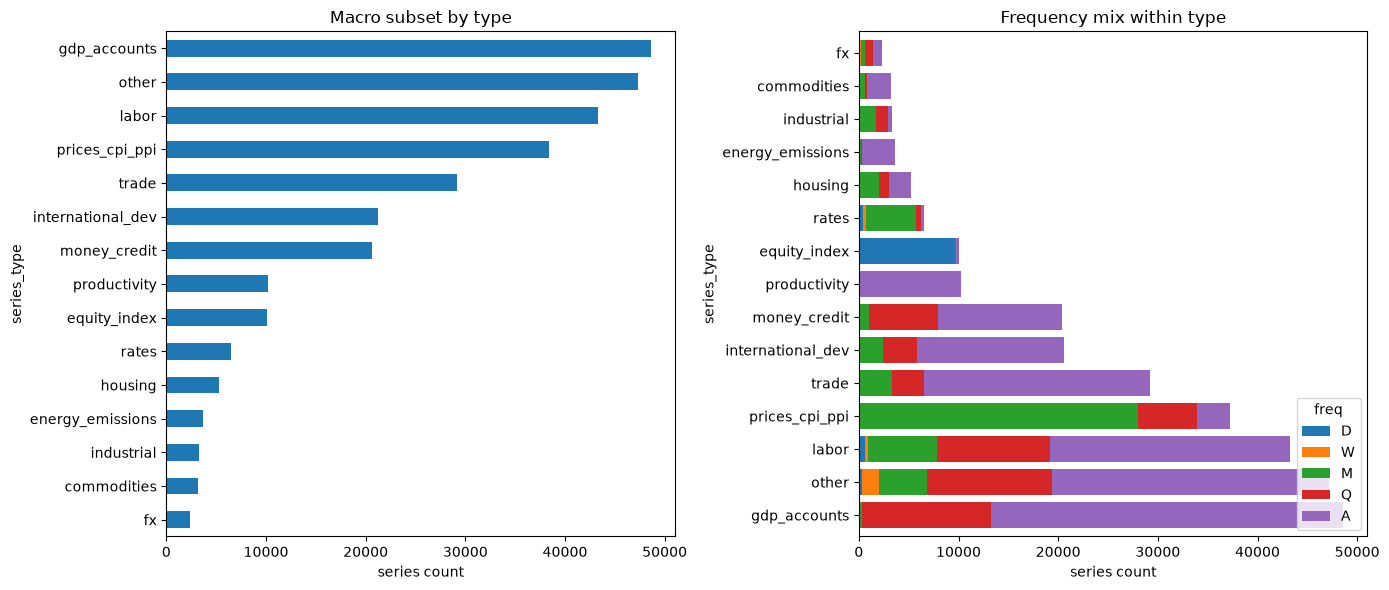

In [16]:
TYPE_RULES = [
    ("rates", re.compile(r"interest rate|treasury|yield|fed funds|federal funds|libor|sofr|mortgage rate|bond yield|discount rate", re.I)),
    ("fx", re.compile(r"exchange rate|foreign exchange|trade.?weighted.*(dollar|currency)|spot rate|currency", re.I)),
    ("prices_cpi_ppi", re.compile(r"consumer price|producer price|cpi|ppi|hicp|deflator|pce price|inflation", re.I)),
    ("equity_index", re.compile(r"nasdaq|s&p|dow jones|stock market|equity index|wilshire|russell", re.I)),
    ("commodities", re.compile(r"crude oil|wti|brent|gold|silver|copper|commodity|natural gas|gasoline", re.I)),
    ("money_credit", re.compile(r"money stock|m1|m2|monetary|credit to|bank credit|reserves|financial access|debt securities", re.I)),
    ("gdp_accounts", re.compile(r"gross domestic product|gdp|national accounts|personal consumption|personal income|gni|value added", re.I)),
    ("trade", re.compile(r"export|import|trade balance|balance of payments|international trade|customs", re.I)),
    ("labor", re.compile(r"unemployment|employment|labor|payroll|earnings|wages|compensation|job", re.I)),
    ("productivity", re.compile(r"productivity|total factor productivity|labor productivity|unit labor", re.I)),
    ("housing", re.compile(r"housing|home price|residential|mortgage(?! rate)|building permit", re.I)),
    ("industrial", re.compile(r"industrial production|capacity utilization|manufacturing|factory", re.I)),
    ("energy_emissions", re.compile(r"energy|emissions|co2|electricity|petroleum", re.I)),
    ("international_dev", re.compile(r"world development|penn world|global financial|main economic indicators|oecd", re.I)),
]


TYPE_RULES = [
    ("rates", re.compile(r"interest rate|treasury|yield|fed funds|federal funds|libor|sofr|mortgage rate|bond yield|discount rate", re.I)),
    ("fx", re.compile(r"exchange rate|foreign exchange|trade.?weighted.*(dollar|currency)|spot rate|\bcurrency\b", re.I)),
    ("prices_cpi_ppi", re.compile(r"consumer price|producer price|\bcpi\b|\bppi\b|hicp|deflator|pce price|inflation", re.I)),
    ("equity_index", re.compile(r"nasdaq|s&p|dow jones|stock market|equity index|wilshire|russell", re.I)),
    ("commodities", re.compile(r"crude oil|wti|brent|\bgold\b|\bsilver\b|copper|commodity|natural gas|gasoline", re.I)),
    ("money_credit", re.compile(r"money stock|\bm1\b|\bm2\b|monetary|credit to|bank credit|reserves|financial access|debt securities", re.I)),
    ("gdp_accounts", re.compile(r"gross domestic product|\bgdp\b|national accounts|personal consumption|personal income|\bgni\b|value added", re.I)),
    ("trade", re.compile(r"export|import|trade balance|balance of payments|international trade|customs", re.I)),
    ("labor", re.compile(r"unemployment|employment|labor|payroll|earnings|wages|compensation|\bjob\b", re.I)),
    ("productivity", re.compile(r"productivity|total factor productivity|labor productivity|unit labor", re.I)),
    ("housing", re.compile(r"housing|home price|residential|building permit", re.I)),
    ("industrial", re.compile(r"industrial production|capacity utilization|manufacturing|factory", re.I)),
    ("energy_emissions", re.compile(r"energy|emissions|co2|electricity|petroleum", re.I)),
    ("international_dev", re.compile(r"world development|penn world|global financial|main economic indicators|oecd", re.I)),
]

text = macro["title"].fillna("") + " " + macro["release_name"].fillna("")
series_type = pd.Series("other", index=macro.index)
for name, pat in TYPE_RULES:
    hit = text.str.contains(pat, na=False) & (series_type == "other")
    series_type.loc[hit] = name

typed = macro.assign(series_type=series_type)
type_counts = typed["series_type"].value_counts()
print(type_counts.to_string())
print(f"\nother share: {100 * type_counts.get('other', 0) / len(typed):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
type_counts.sort_values().plot.barh(ax=axes[0], color="C0")
axes[0].set_title("Macro subset by type")
axes[0].set_xlabel("series count")

freq_by_type = (
    typed.groupby(["series_type", "frequency_short"]).size()
    .unstack(fill_value=0)
    .reindex(type_counts.index)
)
freq_cols = [c for c in ["D", "W", "M", "Q", "A"] if c in freq_by_type.columns]
freq_by_type[freq_cols].plot.barh(stacked=True, ax=axes[1], width=0.8)
axes[1].set_title("Frequency mix within type")
axes[1].set_xlabel("series count")
axes[1].legend(title="freq", loc="lower right")
plt.tight_layout()

for t in list(type_counts.head(5).index) + (["other"] if "other" in type_counts.index else []):
    print(f"\n=== {t} ({type_counts[t]:,}) sample ===")
    print(typed.loc[typed["series_type"] == t, ["id", "title", "release_name"]].head(5).to_string(index=False))


## Athena core macro — **daily only** (~30–45 series)

Curated allowlist, not a ranking of the 293k set. **Daily native frequency only** (drops CPI/UNRATE/GDP — those aren’t daily on FRED).

**Commodities note:** FRED’s usable daily commodity coverage is mostly **EIA energy** (WTI/Brent, nat gas, heating oil, jet fuel, propane). Spot gold/LME metals/grains on FRED are usually **monthly** — for daily metals/ag use Markets (yfinance/Stooq), not FRED.

Athena daily core: 30 series
commodities: 8


,id,label,title,frequency,obs_start,obs_end,span_years,in_catalog
0,DFF,Fed Funds Effective,Federal Funds Effective Rate,D,1954-07-01,2026-08-20,72.136893,True
10,DPRIME,Bank prime rate,Bank Prime Loan Rate,D,1955-08-04,2026-08-20,71.044490,True
3,DGS10,10Y Treasury,Market Yield on U.S. Treasury Securities at 10...,D,1962-01-02,2026-08-20,64.629706,True
2,DGS5,5Y Treasury,Market Yield on U.S. Treasury Securities at 5-...,D,1962-01-02,2026-08-20,64.629706,True
13,DEXJPUS,JPY/USD,Japanese Yen to U.S. Dollar Spot Exchange Rate,D,1971-01-04,2026-08-14,55.608487,True
15,DEXCAUS,CAD/USD,Canadian Dollars to U.S. Dollar Spot Exchange ...,D,1971-01-04,2026-08-14,55.608487,True
16,DEXUSUK,USD/GBP,U.S. Dollars to U.K. Pound Sterling Spot Excha...,D,1971-01-04,2026-08-14,55.608487,True
17,DEXSZUS,CHF/USD,Swiss Francs to U.S. Dollar Spot Exchange Rate,D,1971-01-04,2026-08-14,55.608487,True
21,NASDAQCOM,Nasdaq Composite,NASDAQ Composite,D,1971-02-05,2026-08-21,55.540041,True
5,T10Y2Y,10Y-2Y spread,10-Year Treasury Constant Maturity Minus 2-Yea...,D,1976-06-01,2026-08-21,50.220397,True


wrote fred_athena_core.parquet


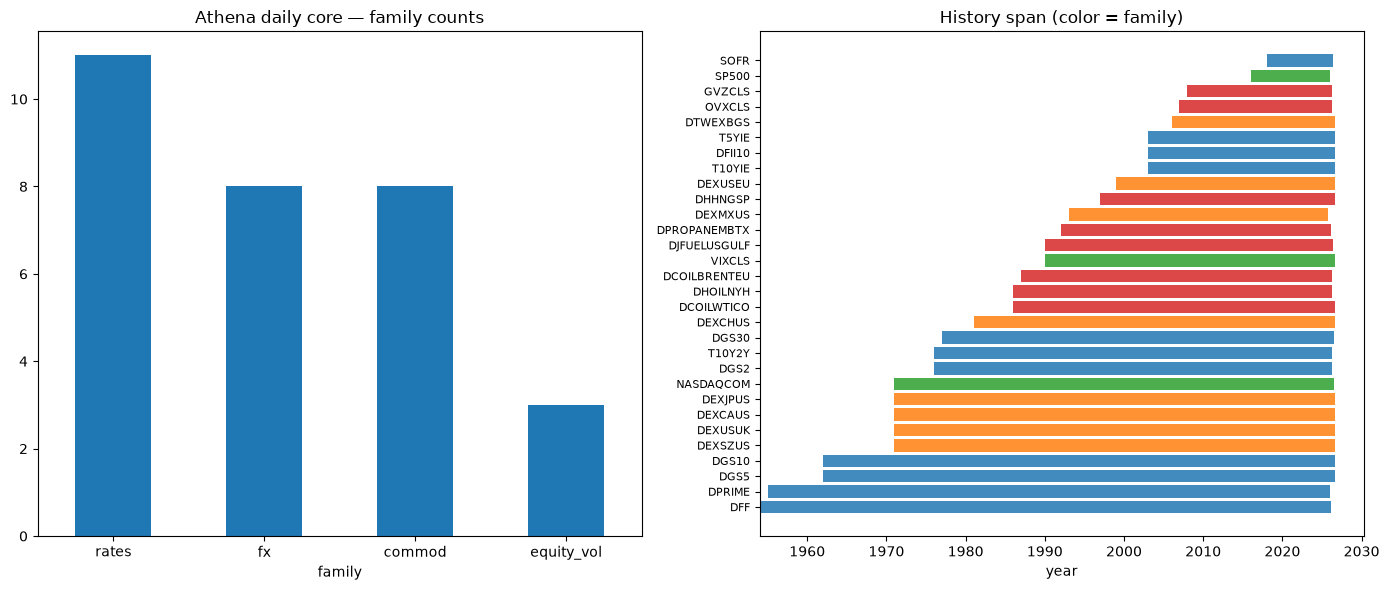

In [17]:
# Athena V1 FRED allowlist — daily native frequency only
ATHENA_CORE = {
    # rates / curve
    "DFF": "Fed Funds Effective",
    "DGS2": "2Y Treasury",
    "DGS5": "5Y Treasury",
    "DGS10": "10Y Treasury",
    "DGS30": "30Y Treasury",
    "T10Y2Y": "10Y-2Y spread",
    "T10YIE": "10Y breakeven inflation",
    "T5YIE": "5Y breakeven inflation",
    "DFII10": "10Y TIPS real yield",
    "SOFR": "SOFR",
    "DPRIME": "Bank prime rate",
    # fx
    "DTWEXBGS": "Broad USD index",
    "DEXUSEU": "USD/EUR",
    "DEXJPUS": "JPY/USD",
    "DEXCHUS": "CNY/USD",
    "DEXCAUS": "CAD/USD",
    "DEXUSUK": "USD/GBP",
    "DEXSZUS": "CHF/USD",
    "DEXMXUS": "MXN/USD",
    # risk / markets (FRED mirrors)
    "SP500": "S&P 500",
    "VIXCLS": "VIX",
    "NASDAQCOM": "Nasdaq Composite",
    # commodities — energy complex (FRED daily strength)
    "DCOILWTICO": "WTI crude",
    "DCOILBRENTEU": "Brent crude",
    "DHHNGSP": "Henry Hub nat gas",
    "DHOILNYH": "NYH heating oil",
    "DJFUELUSGULF": "Gulf Coast jet fuel",
    "DPROPANEMBTX": "Mont Belvieu propane",
    "OVXCLS": "Oil ETF vol (OVX)",
    "GVZCLS": "Gold ETF vol (GVZ)",
}

meta = catalog.drop_duplicates("id").set_index("id") if "catalog" in dir() else None

rows = []
for sid, label in ATHENA_CORE.items():
    if meta is not None and sid in meta.index:
        m = meta.loc[sid]
        rows.append({
            "id": sid,
            "label": label,
            "title": m["title"],
            "frequency": m["frequency_short"],
            "obs_start": m["observation_start"],
            "obs_end": m["observation_end"],
            "span_years": m["span_years"],
            "in_catalog": True,
        })
    else:
        s = fred_get("series", series_id=sid)["seriess"][0]
        start, end = pd.to_datetime(s["observation_start"]), pd.to_datetime(s["observation_end"])
        rows.append({
            "id": sid,
            "label": label,
            "title": s["title"],
            "frequency": s["frequency_short"],
            "obs_start": start,
            "obs_end": end,
            "span_years": (end - start).days / 365.25,
            "in_catalog": False,
        })

core_df = pd.DataFrame(rows)
assert (core_df["frequency"] == "D").all(), core_df.loc[core_df["frequency"] != "D", ["id", "frequency"]]
print(f"Athena daily core: {len(core_df)} series")
print(f"commodities: {sum(1 for k in ATHENA_CORE if k.startswith(('DCOIL','DHH','DHOIL','DJFUEL','DPROP','OVX','GVZ')))}")
display(core_df.sort_values("span_years", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
core_df["family"] = core_df["id"].map(lambda i: (
    "commod" if i.startswith(("DCOIL", "DHH", "DHOIL", "DJFUEL", "DPROP", "OVX", "GVZ")) else
    "fx" if i.startswith(("DTWEX", "DEX")) else
    "equity_vol" if i in {"SP500", "VIXCLS", "NASDAQCOM"} else
    "rates"
))
core_df["family"].value_counts().plot.bar(ax=axes[0], color="C0")
axes[0].set_title("Athena daily core — family counts")
axes[0].tick_params(axis="x", rotation=0)

sample = core_df.sort_values("obs_start")
colors = {"rates": "C0", "fx": "C1", "equity_vol": "C2", "commod": "C3"}
for i, row in enumerate(sample.itertuples()):
    axes[1].barh(i, row.span_years, left=pd.Timestamp(row.obs_start).year, height=0.8,
                 color=colors[row.family], alpha=0.85)
axes[1].set_yticks(range(len(sample)))
axes[1].set_yticklabels(sample["id"], fontsize=8)
axes[1].set_title("History span (color = family)")
axes[1].set_xlabel("year")
plt.tight_layout()

core_df.to_parquet("fred_athena_core.parquet")
print("wrote fred_athena_core.parquet")


## Athena core — pull & plot histories

Fetch full observation histories for the daily allowlist (FRED mode). Grouped by family; levels are raw (not ALFRED).

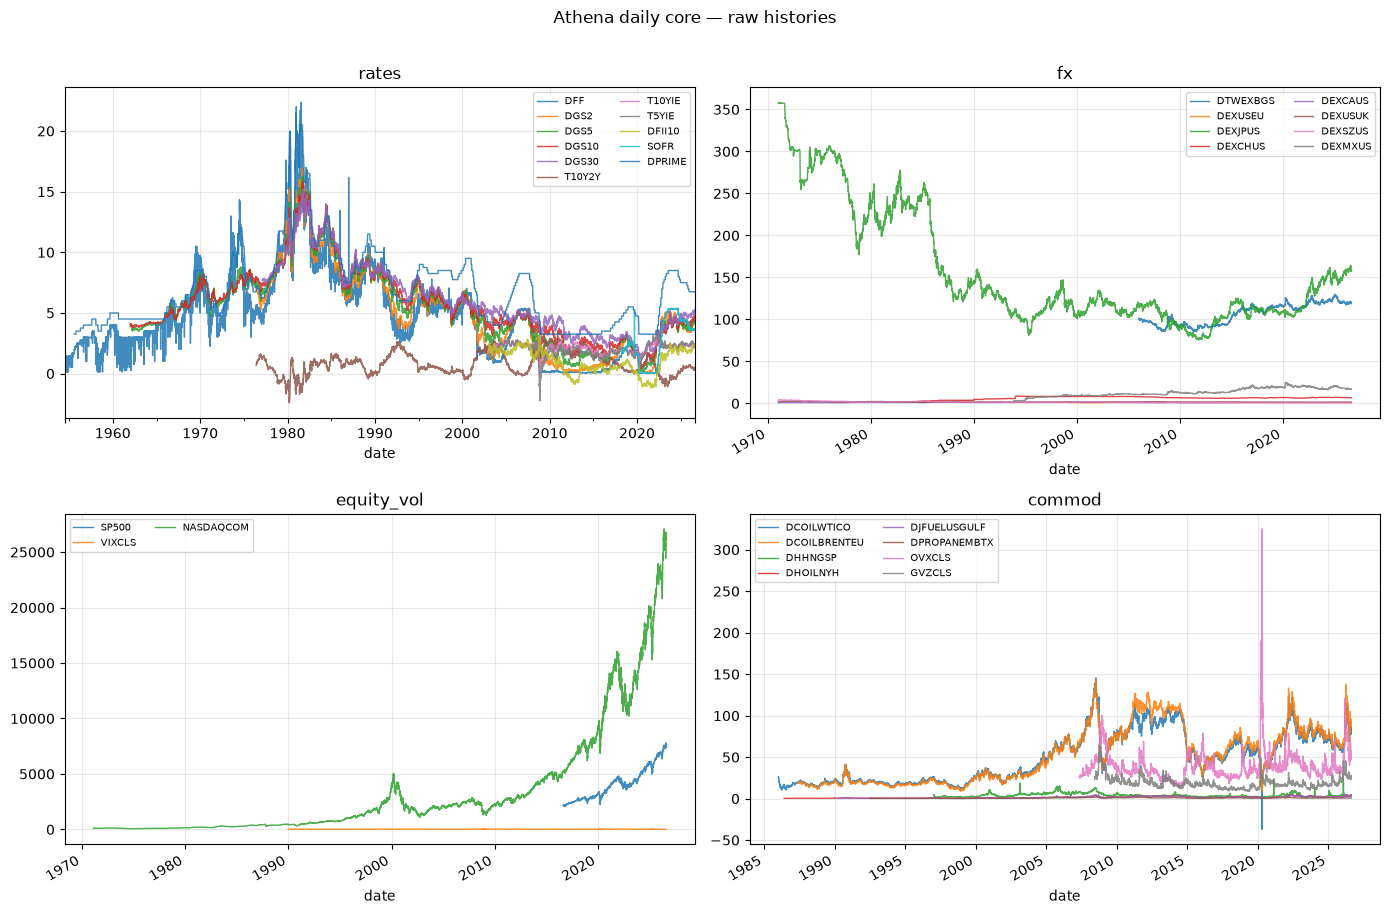

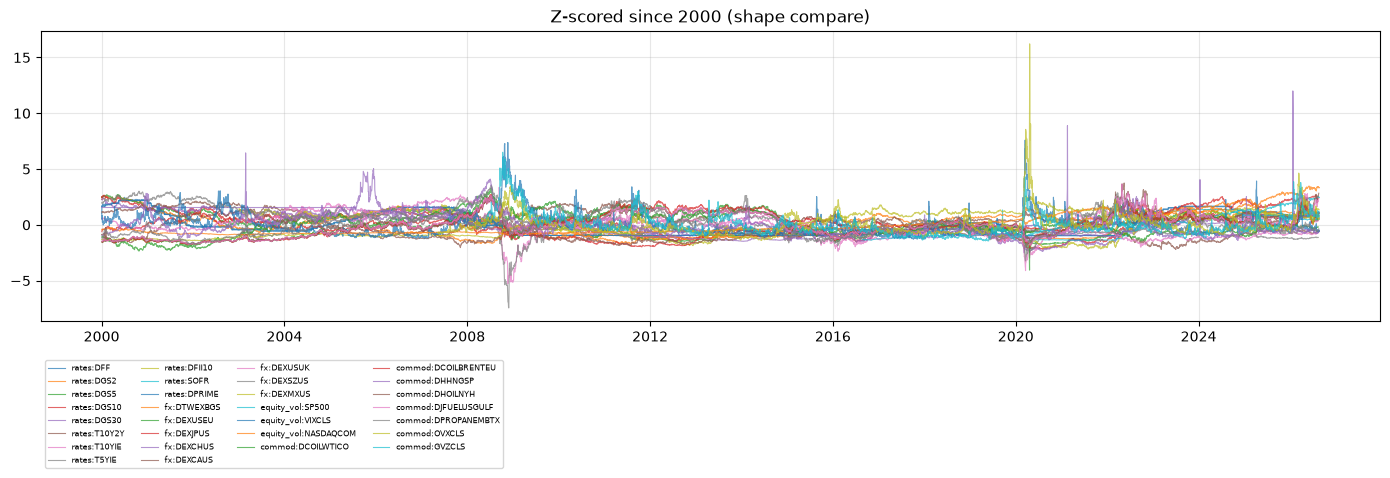

In [18]:
import time

FAMILIES = {
    "rates": [i for i in ATHENA_CORE if i.startswith(("DFF", "DGS", "T10", "T5", "DFII", "SOFR", "DPRIME"))],
    "fx": [i for i in ATHENA_CORE if i.startswith(("DTWEX", "DEX"))],
    "equity_vol": [i for i in ATHENA_CORE if i in {"SP500", "VIXCLS", "NASDAQCOM"}],
    "commod": [i for i in ATHENA_CORE if i.startswith(("DCOIL", "DHH", "DHOIL", "DJFUEL", "DPROP", "OVX", "GVZ"))],
}

hist = {}
for sid in ATHENA_CORE:
    obs = fred_get("series/observations", series_id=sid)
    df = pd.DataFrame(obs["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    hist[sid] = df.dropna(subset=["value"]).set_index("date")["value"]
    time.sleep(0.55)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
for ax, (fam, ids) in zip(axes.ravel(), FAMILIES.items()):
    for sid in ids:
        hist[sid].plot(ax=ax, lw=1, alpha=0.85, label=sid)
    ax.set_title(fam)
    ax.legend(fontsize=7, loc="best", ncol=2)
    ax.grid(True, alpha=0.3)
plt.suptitle("Athena daily core — raw histories", y=1.01)
plt.tight_layout()

# z-score overlay since ~2000 (common window) for cross-series shape
fig, ax = plt.subplots(figsize=(14, 5))
start = "2000-01-01"
for fam, ids in FAMILIES.items():
    for sid in ids:
        s = hist[sid].loc[start:]
        if len(s) < 50:
            continue
        z = (s - s.mean()) / s.std()
        ax.plot(z.index, z.values, lw=0.8, alpha=0.7, label=f"{fam}:{sid}")
ax.set_title("Z-scored since 2000 (shape compare)")
ax.legend(fontsize=6, ncol=4, loc="upper left", bbox_to_anchor=(0, -0.12))
ax.grid(True, alpha=0.3)
plt.tight_layout()
